In [1]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np
from numpy import pi as π, sin,cos

In [2]:
path = "./"
filename= "CHSH_fixed_a0.25_b0.25_Pt_0.9107_100_points_1.5E+04_states_SIM_28_05_2026_17_15_24.csv"
chsh_mixed = pd.read_csv(path+filename, header=None)

In [8]:
def analytical_CHSH(theta_FSS, alpha, beta, Pt=1.0):
    """ Analytical model for CHSH quantity """
    if Pt == 1.0:
        P_HH = P_HV = P_VH = P_VV = 0.0
    else:
        P_HH = 0.0030
        P_HV = 0.0138
        P_VH = 0.0278
        P_VV = 0.0447

    # Qiskit's ry(angle) applies a Bloch rotation corresponding to 2 * physical angle
    # The CHSH equations expect 2*phi_a terms, which exactly match the Bloch angles.
    C_0 = cos(0)
    C_1 = cos(alpha)
    C_2 = cos(alpha + beta)
    C_3 = cos(3 * π / 8)

    S_0 = sin(0)
    S_1 = sin(alpha)
    S_2 = sin(alpha + beta)
    S_3 = sin(3 * π / 8)
    C_theta = cos(theta_FSS)
    term1 = (Pt + P_HH + P_VV - P_HV - P_VH) * (
        C_0 * (C_1 - C_3) + C_2 * (C_3 + C_1)
    )
    term2 = Pt * C_theta * (
        S_0 * (S_1 - S_3) + S_2 * (S_3 - S_1)
    )

    return term1 + term2


def correlation_computing(n_execs: int, n_phase: int, experiment: np.ndarray, calc_type: str, fixed_beta=None):
    theta = np.linspace(0, 2*pi, n_phase)
    alpha = global_alpha
    Pt_val = 0.9107
    
    if n_execs > 1 and fixed_beta is None:
        # Full Mesh Mode (2D)
        beta = np.linspace(0, pi, n_execs)
        if calc_type == 'corr':
            theoretical = np.array([[model_noise(θ=t, β=b, α=alpha, Pt=Pt_val) for b in beta] for t in theta])
        else:
            theoretical = np.array([[analytical_CHSH(theta_FSS=t, alpha=alpha, beta=b, Pt=Pt_val) for b in beta] for t in theta])
    else:
        # Fixed Alpha/Beta Mode (1D Sweep)
        beta_val = fixed_beta if fixed_beta is not None else 0.0
        if calc_type == 'corr':
            theoretical = np.array([model_noise(θ=t, α=alpha, β=beta_val, Pt=Pt_val) for t in theta])
        else:
            theoretical = np.array([analytical_CHSH(theta_FSS=t, alpha=alpha, beta=beta_val, Pt=Pt_val) for t in theta])
            
    return r2(y_true=theoretical.flatten(), y_pred=experiment.flatten())


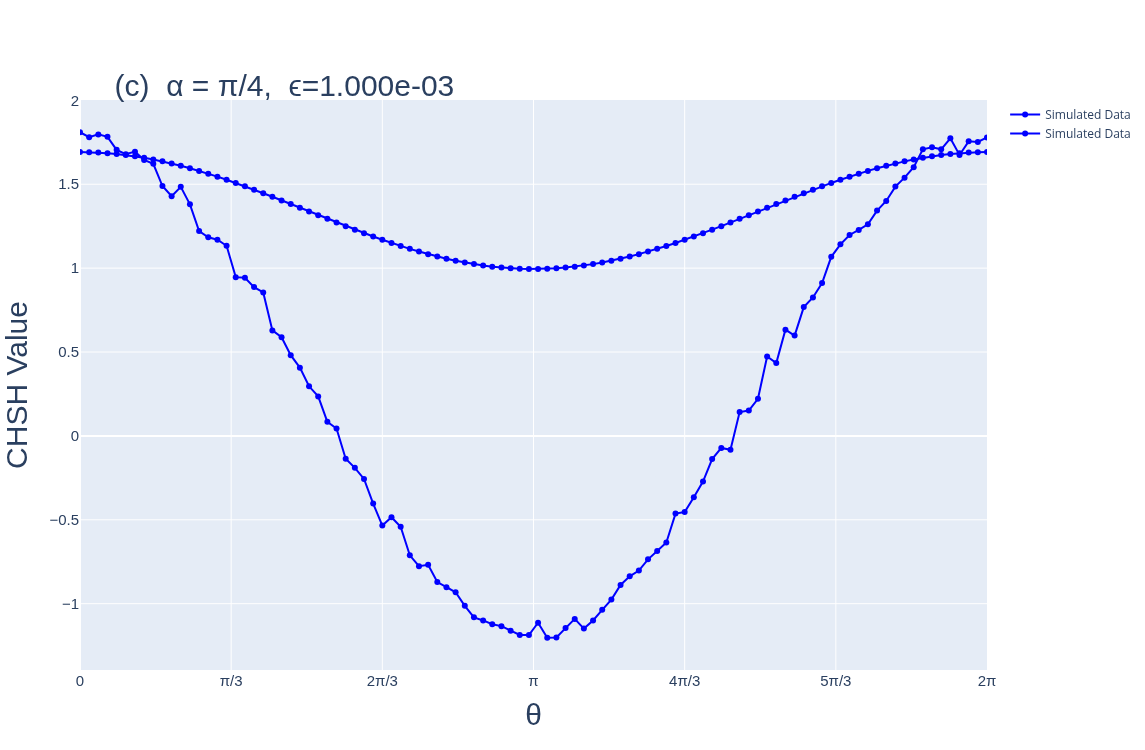

In [10]:
# Flatten the data to a 1D array (handles both single row or single column CSVs)
y_data = chsh_mixed.to_numpy().flatten()
N_data = len(y_data)

# 4. Create the corresponding θ
θ = np.linspace(0, 2 * np.pi, N_data)

# 1. Variables for formatting quantities outside figure
tick_font_size = 15
axes_label_font_size = 30
title_fontsize = 30
font_family = "Arial"

# Placeholder for epsilon - update to your actual ϵ value
ϵ_val = 1e-3 

# Initialize Plotly figure
fig = go.Figure()

# Add the data trace
fig.add_trace(go.Scatter(
    x=θ, 
    y=y_data, 
    mode='lines+markers', 
    name='Simulated Data',
    line=dict(color='blue', width=2)
))
fig.add_trace(go.Scatter(
    x=θ, 
    y=analytical_CHSH(theta_FSS=θ,alpha=π/8,beta=π/8,Pt=0.9107), 
    mode='lines+markers', 
    name='Simulated Data',
    line=dict(color='blue', width=2)
))

# 2 & 3. Update the layout with the specific formatting required
fig.update_layout(
    xaxis=dict(
        title=dict(
            text='θ',
            font=dict(size=axes_label_font_size, family=font_family)
        ), 
        tickfont=dict(size=tick_font_size, family=font_family),                    
        tickmode='array',
        tickvals=[0, np.pi/3, 2*np.pi/3, np.pi, 4*np.pi/3, 5*np.pi/3, 2*np.pi],
        ticktext=['0', 'π/3', '2π/3', 'π', '4π/3', '5π/3', '2π'],
        range=[0, 2 * np.pi]
    ),
    yaxis=dict(
        title=dict(
            text='CHSH Value',  # Update y-axis label as needed
            font=dict(size=axes_label_font_size, family=font_family)
        ),
        tickfont=dict(size=tick_font_size, family=font_family)
    ),
    title=dict(
        text=f"(c)\t\tα = π/4,  ϵ={ϵ_val:1.3e}",
        font=dict(size=title_fontsize, family=font_family),
        x=0.1, 
        y=0.9
    ),
    autosize=False,
    width=750,
    height=750,
    margin=dict(l=80, r=40, t=100, b=80) # Added margin so large labels are not cut off
)

# Display the figure
fig.show()